# Live Coding Kecerdasan Artifisial Lanjut


---
## Bab 9. Clustering K-Means dan DBSCAN


Nama: Hassan Nashrallah

NIM: 245150200111025

### 1) Import Data

Dataset ini berisi data kualitas udara yang direpresentasikan oleh dua fitur utama: **NO2** (konsentrasi nitrogen dioksida di udara) dan **Proximity_to_Industrial_Areas** (jarak ke kawasan industri terdekat). Kedua fitur ini digunakan untuk merepresentasikan potensi tingkat pencemaran udara di suatu lokasi. Meskipun dataset ini memiliki label asli bernama **Air Quality** yang dikategorikan menjadi *Good*, *Moderate*, *Poor*, dan *Hazardous*, label tersebut nantinya **harus dihapus** dalam analisis clustering. Dataset ini sebelumnya telah digunakan dalam ujian tengah semester untuk supervised learning, namun pada praktik kali ini akan digunakan untuk mengeksplorasi kemampuan algoritma unsupervised seperti KMeans dan DBSCAN dalam mengelompokkan data tanpa bantuan label, lalu membandingkan hasilnya dengan label asli secara terpisah.

In [ ]:
import pandas as pd
df = pd.read_csv('air_quality_clustering.csv')



Cek isi dataset Anda dengan menggunakan perintah **head()**

In [2]:
df.head()

,NO2,Proximity_to_Industrial_Areas,Air Quality
0,18.9,6.3,Moderate
1,30.8,6.0,Moderate
2,24.4,5.2,Moderate
3,13.5,11.1,Good
4,21.9,12.7,Good


## 2) Preprocessing

Sebelum dilakukan proses clustering, perlu dilakukan beberapa tahapan pemrosesan awal data. Tahapan pertama adalah memisahkan kelas data dari dataframe, karena algoritma K-Means tidak memerlukan informasi kelas. Pisahkan kelas data ke dalam sebuah variabel bernama kelas.


In [3]:
kelas=df.pop('Air Quality')

Salah satu tahap pada algoritma clustering adalah perhitungan jarak Euclidean. Agar tidak ada fitur yang mendominasi pada perhitungan jarak, maka perlu dilakukan normalisasi terlebih dahulu agar rentang nilai setiap fitur sama. Implementasikan metode normalisasi min-max menggunakan fungsi bernama minmax pada cell di bawah ini.

In [4]:
def minmax(df):
    list_fitur = df.columns[:-1]
    for fitur in list_fitur:
        max = df[fitur].max()
        min = df[fitur].min()
        df[fitur] = (df[fitur] - min) / (max - min)
    return df

Lakukan normalisasi data dan simpan hasilnya pada variabel bernama data_normal

In [5]:
data_normal = minmax(df)

Tampilkan isi dataframe data_normal

In [6]:
data_normal

,NO2,Proximity_to_Industrial_Areas
0,0.200000,6.3
1,0.406957,6.0
2,0.295652,5.2
3,0.106087,11.1
4,0.252174,12.7
...,...,...
4995,0.662609,2.8
4996,0.311304,5.7
4997,0.476522,9.6
4998,0.283478,11.6


## 3) Visualisasi Data

Visualisasi data dilakukan untuk memahami struktur dari data. Informasi ini dapat digunakan untuk mengetahui cara pembentukan cluster yang baik. Visualisasikan data_normal menggunakan scatter plot. Gunakan library matplotlib.pyplot

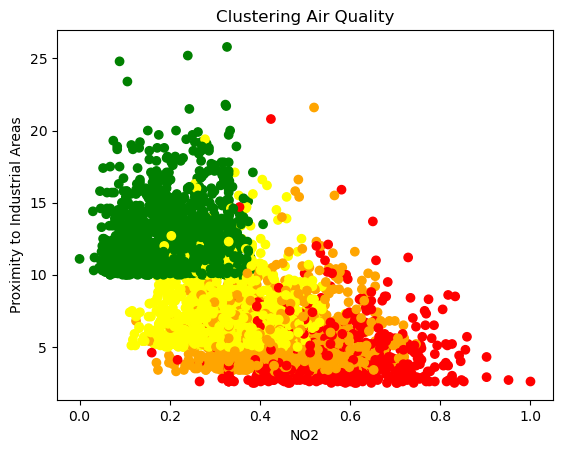

In [7]:
import matplotlib.pyplot as plt

warna = {'Good': 'green', 'Moderate': 'yellow', 'Poor': 'orange', 'Hazardous': 'red'}
plt.scatter(data_normal['NO2'], data_normal['Proximity_to_Industrial_Areas'], c=kelas.map(warna))
plt.xlabel('NO2')
plt.ylabel('Proximity to Industrial Areas')
plt.title('Clustering Air Quality')
plt.show()

## 4)  K-MEANS Clustering

Sebelum mengimplementasikan algoritma K-Means, perlu dilakukan implementasi perhitungan jarak. K-Means pada praktikum ini menggunakan perhitungan jarak Euclidean. Implementasikan perhitungan jarak Euclidean menggunakan fungsi bernama euclidean pada cell di bawah ini

In [8]:
from random import randint
import copy
import numpy as np

def euclidean(data1,data2):
    jarak = np.square(data1 - data2)
    jarak = np.sum(jarak)
    return np.sqrt(jarak)



Langkah selanjutnya adalah implementasi algoritma K-Means. Tahapan-tahapan dalam algoritma K-Means adalah:
1. Penentuan keanggotaan cluster secara acak
2. Hitung centroid berdasarkan data yang ada di masing-masing cluster
3. Alokasikan masing-masing data ke centroid terdekat
4. Kembali ke langkah 2 selama kondisi berhenti belum terpenuhi.
   *   Iterasi berhenti jika salah satu kondisi berikut terpenuhi
   *   Tidak ada perubahan keanggotaan cluster b. Iterasi melebihi parameter iter_max



Implementasikan algoritma K-Means menggunakan fungsi bernama kmeans pada cell di bawah ini. Fungsi kmeans memiliki 3 parameter input, yaitu data, K, dan iter_max

In [9]:
def kmeans(data_input, k, iter_max=200):
    n_data = data_input.shape[0]
    n_fitur = data_input.shape[1]
    iter = 1
    cluster = np.array([randint(0, k-1) for i in range(n_data)])
    centroid = np.zeros((k, n_fitur))
    cluster_tidak_berubah = False
    while not cluster_tidak_berubah and iter < iter_max:
        jarak = np.zeros((n_data, k))
        for i in range(k):
            centroid[i,:] = data_input.iloc[np.where(cluster == i)[0]].mean().tolist()
        for i in range(n_data):
            for j in range(k):
                jarak[i,j] = euclidean(data_input.iloc[i], centroid[j])
        cluster_baru = [np.argmin(jarak[i]) for i in range(n_data)]
        cluster_tidak_berubah = np.array_equal(cluster_baru, cluster)
        cluster = np.array(copy.deepcopy(cluster_baru))
        iter += 1
    return cluster, centroid, jarak

Lakukan proses clustering dengan memanggil fungsi kmeans dengan parameter input berupa data_normal dan k=3.

In [17]:
cluster=kmeans(data_normal,3)

Tampilkan keanggotaan cluster pada masing-masing data

In [18]:
print(cluster)

(array([2, 2, 2, ..., 0, 1, 0], shape=(5000,)), array([[ 0.35256751,  8.16165254],
       [ 0.23045392, 12.11674901],
       [ 0.42035507,  4.8711122 ]]), array([[1.86789374, 5.81682873, 1.44577892],
       [2.16233667, 6.11929503, 1.1289673 ],
       [2.96219937, 6.91705629, 0.35173569],
       ...,
       [1.44367866, 2.52874968, 4.72922134],
       [3.43904152, 0.51946234, 6.7302798 ],
       [0.15871518, 3.81700643, 3.43197652]], shape=(5000, 3)))


Tampilkan hasil clustering menggunakan scatter plot

[]

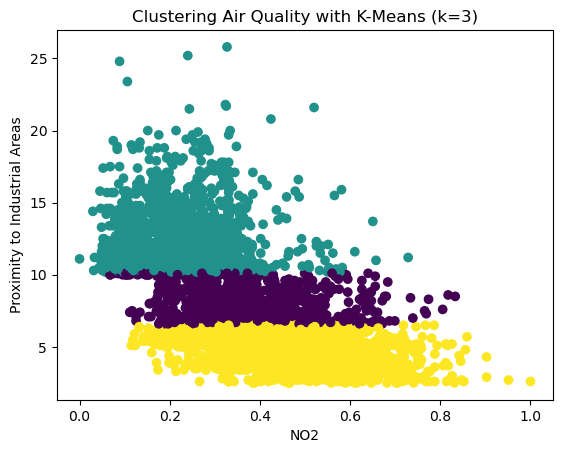

In [19]:
plt.scatter(data_normal['NO2'], data_normal['Proximity_to_Industrial_Areas'], c=cluster[0])
plt.xlabel('NO2')
plt.ylabel('Proximity to Industrial Areas')
plt.title('Clustering Air Quality with K-Means (k=3)')
plt.plot()

## 5) DBSCAN Clustering

Pada praktikum ini, implementasikan algoritma DBSCAN menggunakan pustaka sklearn. Terdapat dua parameter penting yang di diatur pada program yaitu eps dan min_sample. Eps adalah jarak maksimum antara dua sampel agar satu sampel dianggap berada di sekitar sampel lainnya. Parameter ini harus dipilih dengan tepat untuk set data dan fungsi jarak. Nilai default dari parameter eps adalah 0.5. Min_sample adalah jumlah sampel (atau bobot total) di lingkungan sekitar agar suatu titik dianggap sebagai titik inti (termasuk titik itu sendiri). Jika min_samples ditetapkan tinggi, maka DBSCAN akan membentuk klaster yang lebih padat, sedangkan jika ditetapkan rendah, maka klaster yang terbentuk akan lebih jarang. Nilai default dari parameter min_sample adalah 5.

In [13]:
from sklearn.cluster import DBSCAN

epsilon = 0.3
min_samples = 5
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
cluster = dbscan.fit_predict(data_normal)

Tampilkan keanggotaan cluster pada masing-masing data

In [14]:
print(cluster)

[0 0 0 ... 0 0 0]


Tampilkan hasil clustering menggunakan scatter plot

[]

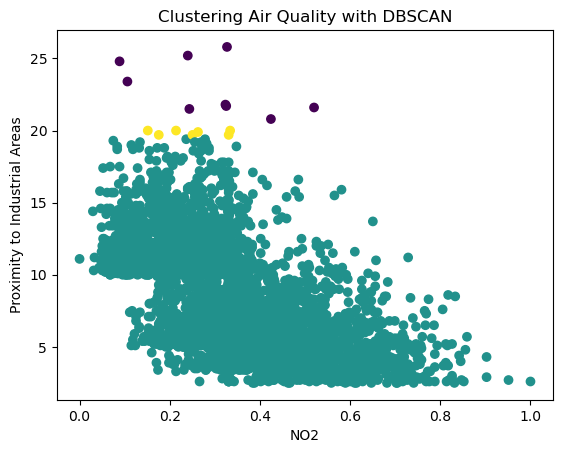

In [15]:
plt.scatter(data_normal['NO2'], data_normal['Proximity_to_Industrial_Areas'], c = cluster)
plt.xlabel('NO2')
plt.ylabel('Proximity to Industrial Areas')
plt.title('Clustering Air Quality with DBSCAN')
plt.plot()

## Pertanyaan
Bandingkan hasil klaster dari KMeans dan DBSCAN — algoritma mana yang lebih mendekati label asli berdasarkan visualisasinya? Mengapa demikian?

Berdasarkan hasil clustering tersebut, algoritma KMeans dengan k=3 menunjukkan pemisahan klaster yang lebih konsisten dengan label asli “Air Quality” dibandingkan DBSCAN. Hal ini disebabkan oleh KMeans yang membagi data berdasarkan jarak Euclidean ke centroid, sehingga dapat menangkap pola linear atau diagonal yang sesuai dengan distribusi kualitas udara. Sementara itu, DBSCAN sangat sensitif terhadap parameter epsilon dan lebih efektif pada data dengan kepadatan tinggi yang terpisah jelas. Pada dataset ini, variasi epsilon pada DBSCAN menghasilkan klaster yang hampir menyatu sehingga tidak merepresentasikan label asli secara akurat. 

